In [2]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches
import IPython.display as ipd
import music21 as m21
import tqdm as tqdm
%reload_ext autoreload
%autoreload 2
from utils import *
import os

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Make a dataset of json files

In [12]:
import os
import json

output_dir = "../song_jsons"
os.makedirs(output_dir, exist_ok=True)

# final_chords: list/array of chords per song
# theOffsetDataset: list/array of offsets per song
# all_meta: list of metadata dicts per song

assert len(formatted_chords) == len(all_meta) == len(theOffsetDataset), "Mismatch in song/chord/offset/meta counts!"

for i, (formatted_chords, meta, offsets) in enumerate(zip(formatted_chords, all_meta, theOffsetDataset)):
    song_data = {
        "metadata": meta,
        "chords": [str(c) for c in formatted_chords],
        "offsets": [float(x) for x in offsets]  # Ensure serializable as float
    }
    song_name = meta["song_name"].replace(" ", "_").replace("'", "").replace("/", "-")
    fname = f"{i:04d}_{song_name}.json"
    with open(os.path.join(output_dir, fname), "w") as f:
        json.dump(song_data, f, indent=2)


In [14]:
tri_list = []
trigram = {}
for i in range(len(final_chords)-3):
    n_1, n_2, n_3 = final_chords[i], final_chords[i+1], final_chords[i+2]
    if n_1 != n_2 and n_2 != n_3 and n_1 != n_3:
        tri_list.append([n_1, n_2, n_3])
        tri = (n_1, n_2, n_3)
        trigram[tri] = trigram.get(tri, 0) + 1

In [15]:
trigram = sorted(trigram.items(), key = lambda kv: -kv[1])
trigram = np.array(trigram, dtype=object)
print(trigram[0])

[('Gm7', 'C7', 'Fmaj7') 518]


In [16]:
t_dict = []
for i in range (len(trigram)):
    a = {}
    a['trigram'] = trigram[i][0]
    a['type'] = i
    a['count'] = trigram[i][1]
    a.update(a)
    t_dict.append(a)

In [17]:
print(list(t_dict[0]['trigram']))
print(tri_list[0])
print(len(tri_list))

['Gm7', 'C7', 'Fmaj7']
['E', 'Fm7', 'Bb7']
121335


In [ ]:
tri_id = []
for e in tqdm(tri_list):
    for c in t_dict:
        if e == list(c['trigram']):
            a = {}
            a['trigram'] = c['trigram']
            a['id'] = c['type']
            tri_id.append(a)

In [ ]:
print(tri_id[2])

{'trigram': ('Eb', 'Am7', 'D7'), 'id': 18278}


In [73]:
np.save("../data/formatted/tri_id.npy", tri_id)

In [19]:
tri_id = np.load("../data/formatted/tri_id.npy", allow_pickle=True)
print(tri_id[2])

{'trigram': ('Eb', 'Am7', 'D7'), 'id': 18278}


In [20]:
#trying to get the bigrams of trigrams
b = {}
for i in range(len(tri_list[:10])-1):
    for j in range(i+1, len(tri_list[:10])):
        t1 = tri_list[i]
        t2 = tri_list[j]
        bigram = (t1, t2)
        print(bigram)
        #b[bigram] = b.get(bigram, 0)+1
        
        
b = sorted(b.items(), key = lambda kv: -kv[1])

(['E', 'Fm7', 'Bb7'], ['Fm7', 'Bb7', 'Eb'])
(['E', 'Fm7', 'Bb7'], ['Eb', 'Am7', 'D7'])
(['E', 'Fm7', 'Bb7'], ['Am7', 'D7', 'G'])
(['E', 'Fm7', 'Bb7'], ['D7', 'G', 'Am7'])
(['E', 'Fm7', 'Bb7'], ['G', 'Am7', 'D7'])
(['E', 'Fm7', 'Bb7'], ['Am7', 'D7', 'G'])
(['E', 'Fm7', 'Bb7'], ['D7', 'G', 'Am7'])
(['E', 'Fm7', 'Bb7'], ['G', 'Am7', 'D7'])
(['E', 'Fm7', 'Bb7'], ['Am7', 'D7', 'Gm7'])
(['Fm7', 'Bb7', 'Eb'], ['Eb', 'Am7', 'D7'])
(['Fm7', 'Bb7', 'Eb'], ['Am7', 'D7', 'G'])
(['Fm7', 'Bb7', 'Eb'], ['D7', 'G', 'Am7'])
(['Fm7', 'Bb7', 'Eb'], ['G', 'Am7', 'D7'])
(['Fm7', 'Bb7', 'Eb'], ['Am7', 'D7', 'G'])
(['Fm7', 'Bb7', 'Eb'], ['D7', 'G', 'Am7'])
(['Fm7', 'Bb7', 'Eb'], ['G', 'Am7', 'D7'])
(['Fm7', 'Bb7', 'Eb'], ['Am7', 'D7', 'Gm7'])
(['Eb', 'Am7', 'D7'], ['Am7', 'D7', 'G'])
(['Eb', 'Am7', 'D7'], ['D7', 'G', 'Am7'])
(['Eb', 'Am7', 'D7'], ['G', 'Am7', 'D7'])
(['Eb', 'Am7', 'D7'], ['Am7', 'D7', 'G'])
(['Eb', 'Am7', 'D7'], ['D7', 'G', 'Am7'])
(['Eb', 'Am7', 'D7'], ['G', 'Am7', 'D7'])
(['Eb', 'Am7', 'D7

In [21]:
for e in b[:10]:
    print(e)

In [22]:
#Delete the repeated sequences with the same chord
id = []
for i in range(len(trigram)):
    a = list(trigram[i][0])
    if a[0] == a[1] or a[1] == a[2]:
        id.append(i)

trigram = np.delete(trigram, id, axis=0)

In [ ]:
np.save("../data/formatted/trigram.npy", trigram)

In [24]:
trigram = np.load("../data/formatted/trigram.npy", allow_pickle=True)
print(trigram[0])

[('Gm7', 'C7', 'Fmaj7') 518]


(46347, 2)
['Gm7 C7 Fmaj7', 'Fm7 Bb7 Ebmaj7', 'Cm7 F7 Bbmaj7', 'Dm7 G7 Cmaj7', 'Gm7 C7 F6', 'Bbm7 Eb7 Abmaj7', 'D7 Gm7 C7', 'A7 Dm7 G7', 'Am7 D7 Gmaj7', 'Gm C7 F']


/tmp/ipykernel_4934/4018642734.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), rotation=45, horizontalalignment='right')


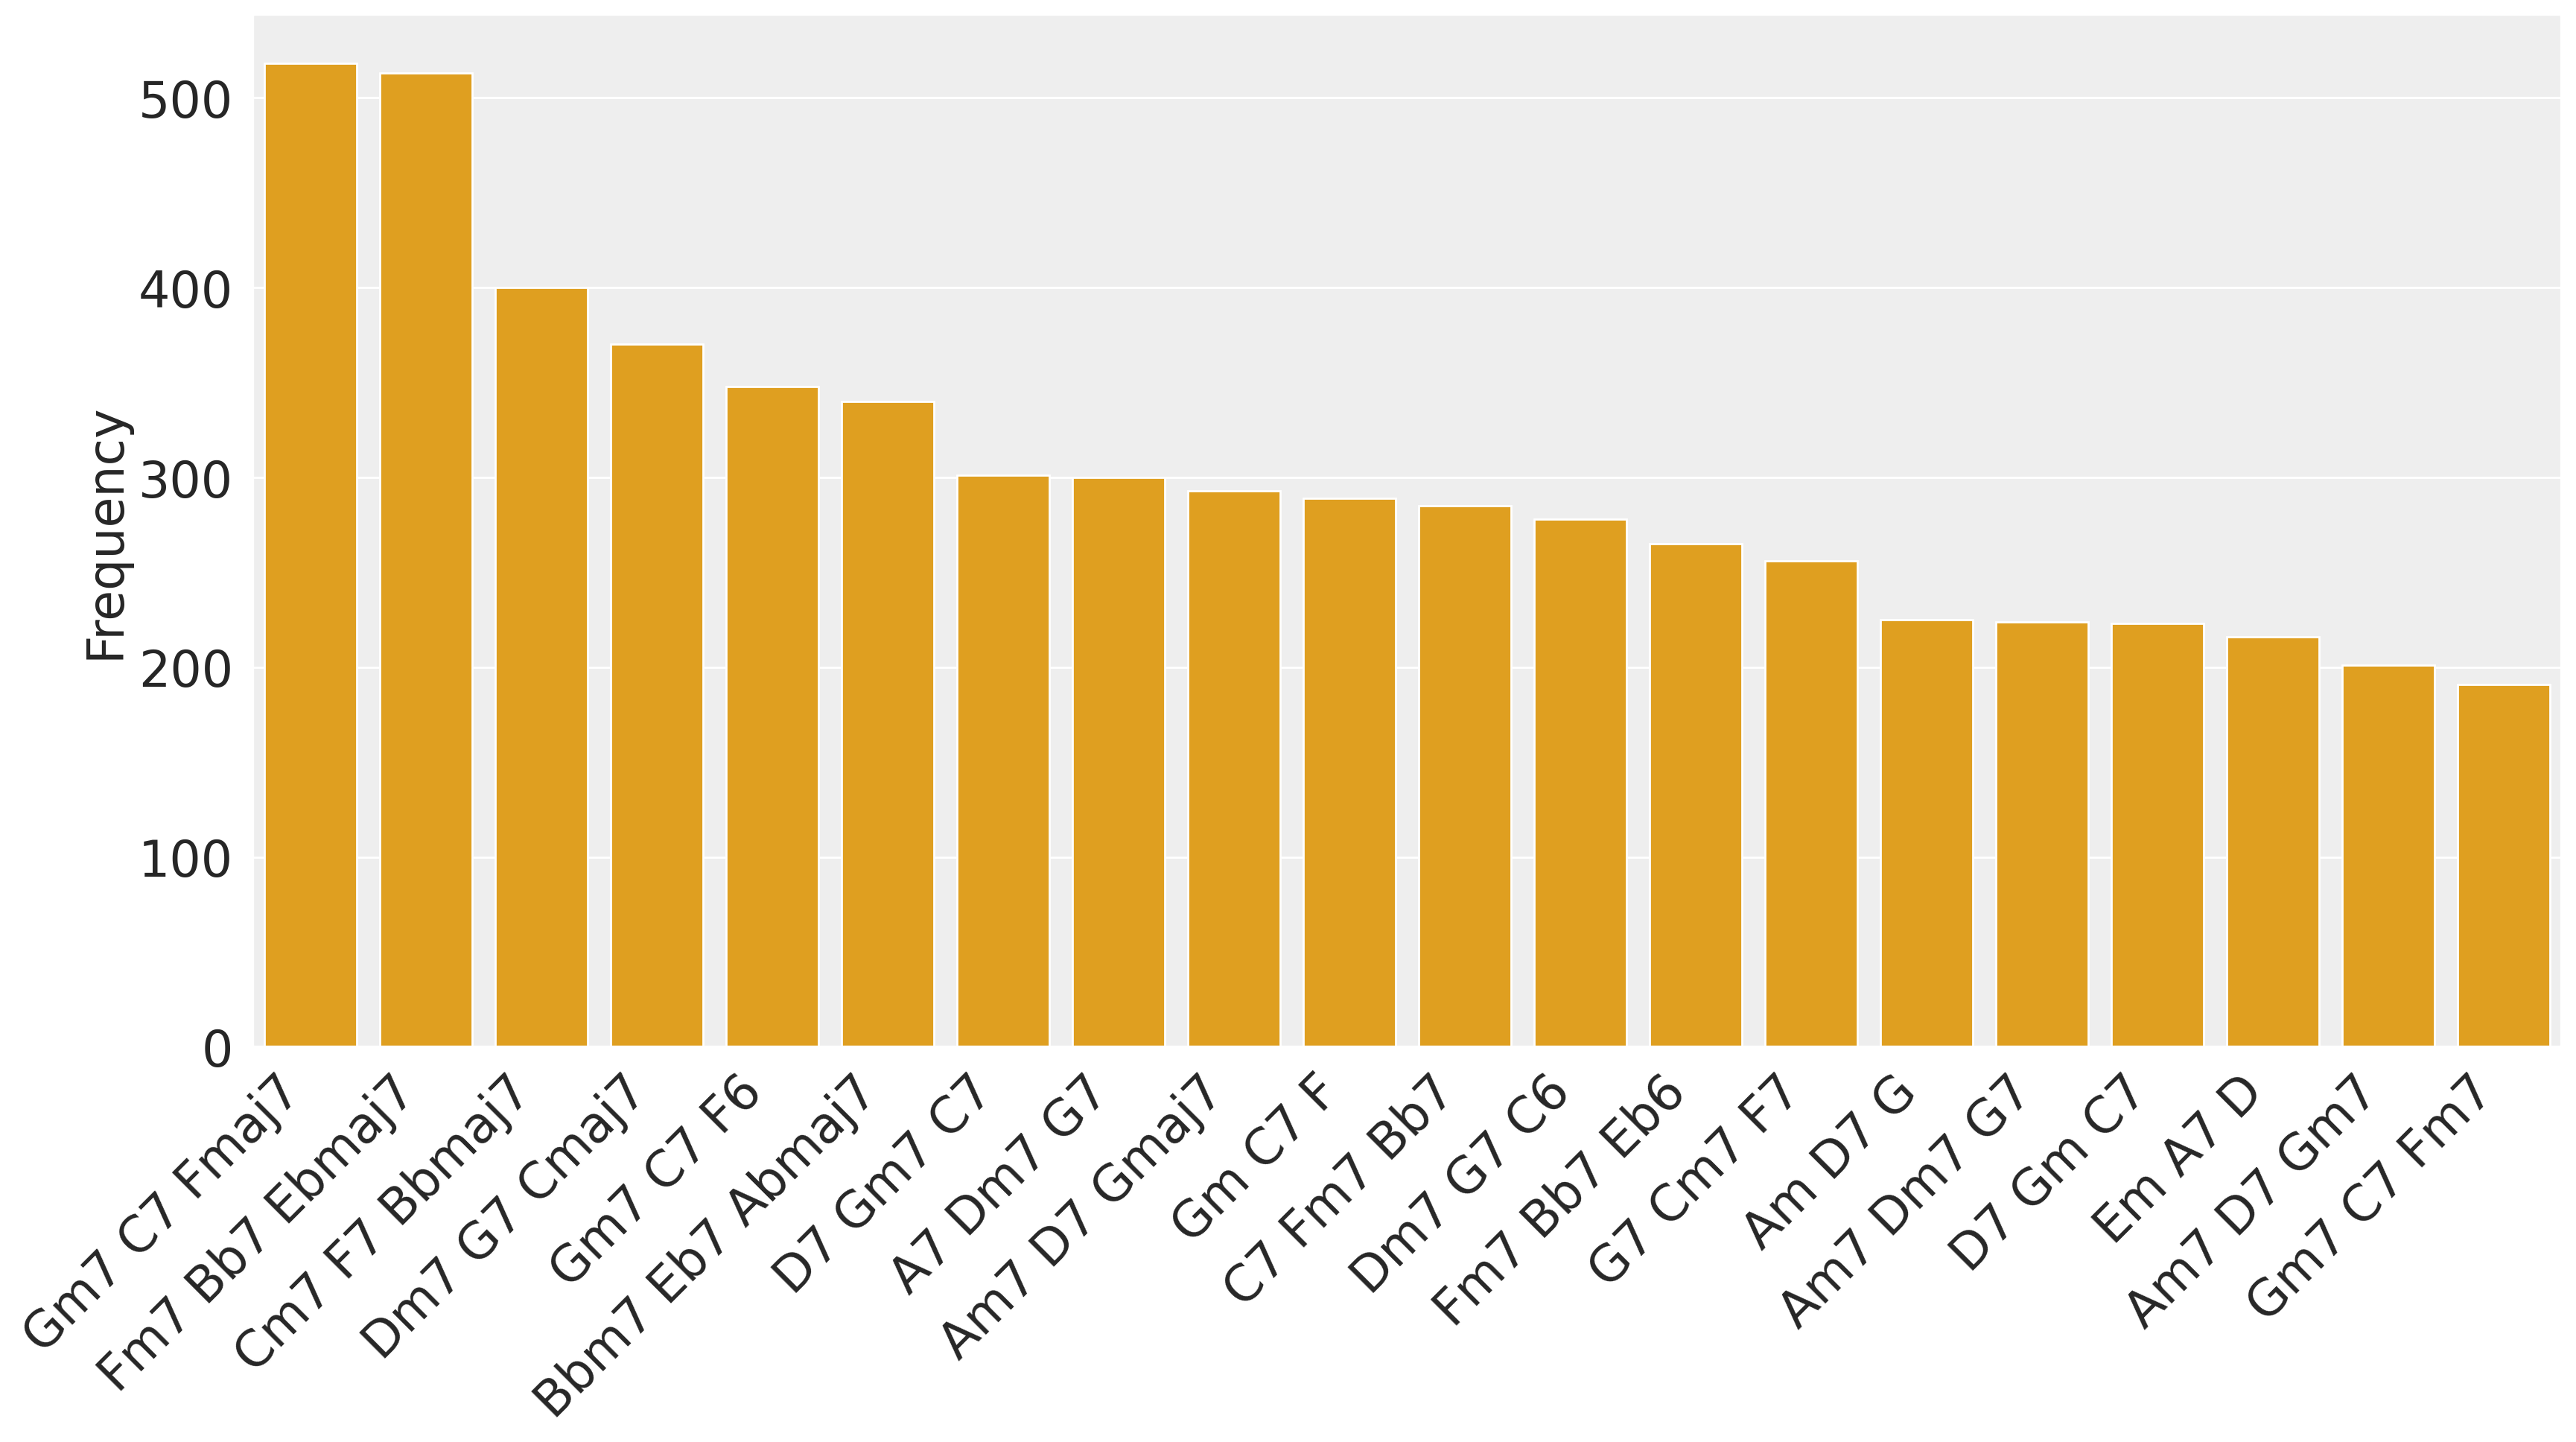

In [25]:
print(trigram.shape)

import seaborn as sns

sns.set(rc={'figure.figsize':(20,9)})
sns.set(font_scale=0.8)
sns.set(rc={'axes.facecolor':'#eee', 'figure.facecolor':'white'})

key = []
for element in trigram[:20]:
    a = ' '.join(element[0])
    a = a.replace('-', 'b')
    key.append(a)

value = []
for element in trigram[:20]:
    value.append(element[1])

print(key[:10])
#with sns.axes_style("whitegrid"):
b = sns.barplot(x=key, y=value, color='#ffaa00') #palette="rainbow"
b.axes.set_title("",fontsize=22)
b.set_xlabel("",fontsize=16)
b.set_xticklabels(b.get_xticklabels(), rotation=45, horizontalalignment='right')
b.set_ylabel("Frequency",fontsize=24)
b.tick_params(labelsize=24)
plt.show()


In [ ]:
#tri = (n_1, n_2, n_3)
#trigram[tri] = trigram.get(tri, 0)+1

functions = {}
for i in tqdm(range(len(trigram))):    
    tri = trigram[i][0]
    s = m21.stream.Stream()
    func = []
    for chord in tri:
        if chord.find('b') > 0 and chord[1:2] == 'b':
            chord = chord[0:1] + '-' + chord[2:]
            #print(chord)
                    
        d = m21.harmony.ChordSymbol(chord)
       
        d.quarterLength = 2
        s.append(d)
    key = s.analyze('key')
    myKey = key.tonic.name + key.mode
    
    for chord in tri:
        if chord.find('b') > 0 and chord[1:2] == 'b':
                chord = chord[0:1] + '-' + chord[2:]
        h = m21.harmony.ChordSymbol(chord)
        h.key = key
        
        func.append(h.romanNumeral.figure)
    
    dict = {'key': myKey, 'function': func}
    functions[i] = dict

data = functions.items()
data = list(data)
functions = np.array(data, dtype=object)

In [ ]:
np.save("../data/formatted/trigram.npy", trigram)
np.save("../data/formatted/functions.npy", functions)

In [ ]:
import re
functions = np.load("../data/formatted/functions.npy", allow_pickle=True)
print(functions[0], trigram[0])
all_func= []
for e in functions:
    s = e[1]['function']
    tri = (s[0], s[1], s[2])
    new_string = ' '.join(filter(lambda x: not x.isdigit(), tri))
    pattern = r'[0-9]'
    data = re.sub(pattern, '', new_string)    
    data = re.sub(r'b$',"", data)
    data = data.replace("b ", " ")
    data = data.replace("bb", "")
    data = data.replace("#", "")
    data = data.replace("+", "")
    all_func.append(data)
all
print(all_func)

In [82]:
np.save("../data/formatted/all_func.npy", all_func)

In [28]:
most_common = {}
for tri in tqdm(all_func):
    most_common[tri] = most_common.get(tri, 0)+1

most_common = sorted(most_common.items(), key = lambda kv: -kv[1])
most_common = np.array(most_common, dtype=object)

print(most_common[:10])

id = []
for i in range(len(most_common)):
    a = most_common[i][0]
    a = a.split(' ')
    if a[0] == a[1] or a[1] == a[2]:
        id.append(i)



100%|██████████| 46347/46347 [00:00<00:00, 1127133.93it/s]

[['V I I' 513]
 ['V I IV' 431]
 ['V i IV' 354]
 ['I I I' 299]
 ['ii V I' 291]
 ['I I IV' 270]
 ['I V I' 243]
 ['IV V I' 226]
 ['bVI V i' 217]
 ['I I V' 213]]


In [29]:
most_common = np.delete(most_common, id, axis=0)

In [30]:
dict_most_common = []
for element in most_common:
    a={}
    a['function'] = element[0]
    a['value'] = element[1]
    dict_most_common.append(a)

In [31]:
for element in dict_most_common[:10]:
    print(element)

{'function': 'V I IV', 'value': 431}
{'function': 'V i IV', 'value': 354}
{'function': 'ii V I', 'value': 291}
{'function': 'I V I', 'value': 243}
{'function': 'IV V I', 'value': 226}
{'function': 'bVI V i', 'value': 217}
{'function': 'V I i', 'value': 199}
{'function': 'V I vi', 'value': 196}
{'function': 'I IV I', 'value': 196}
{'function': 'V I VI', 'value': 177}


['V-I-IV', 'V-i-IV', 'ii-V-I', 'I-V-I', 'IV-V-I', 'bVI-V-i', 'V-I-i', 'V-I-vi', 'I-IV-I', 'V-I-VI']


/tmp/ipykernel_4934/1208507729.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(b.get_xticklabels(), rotation=45, horizontalalignment='right')


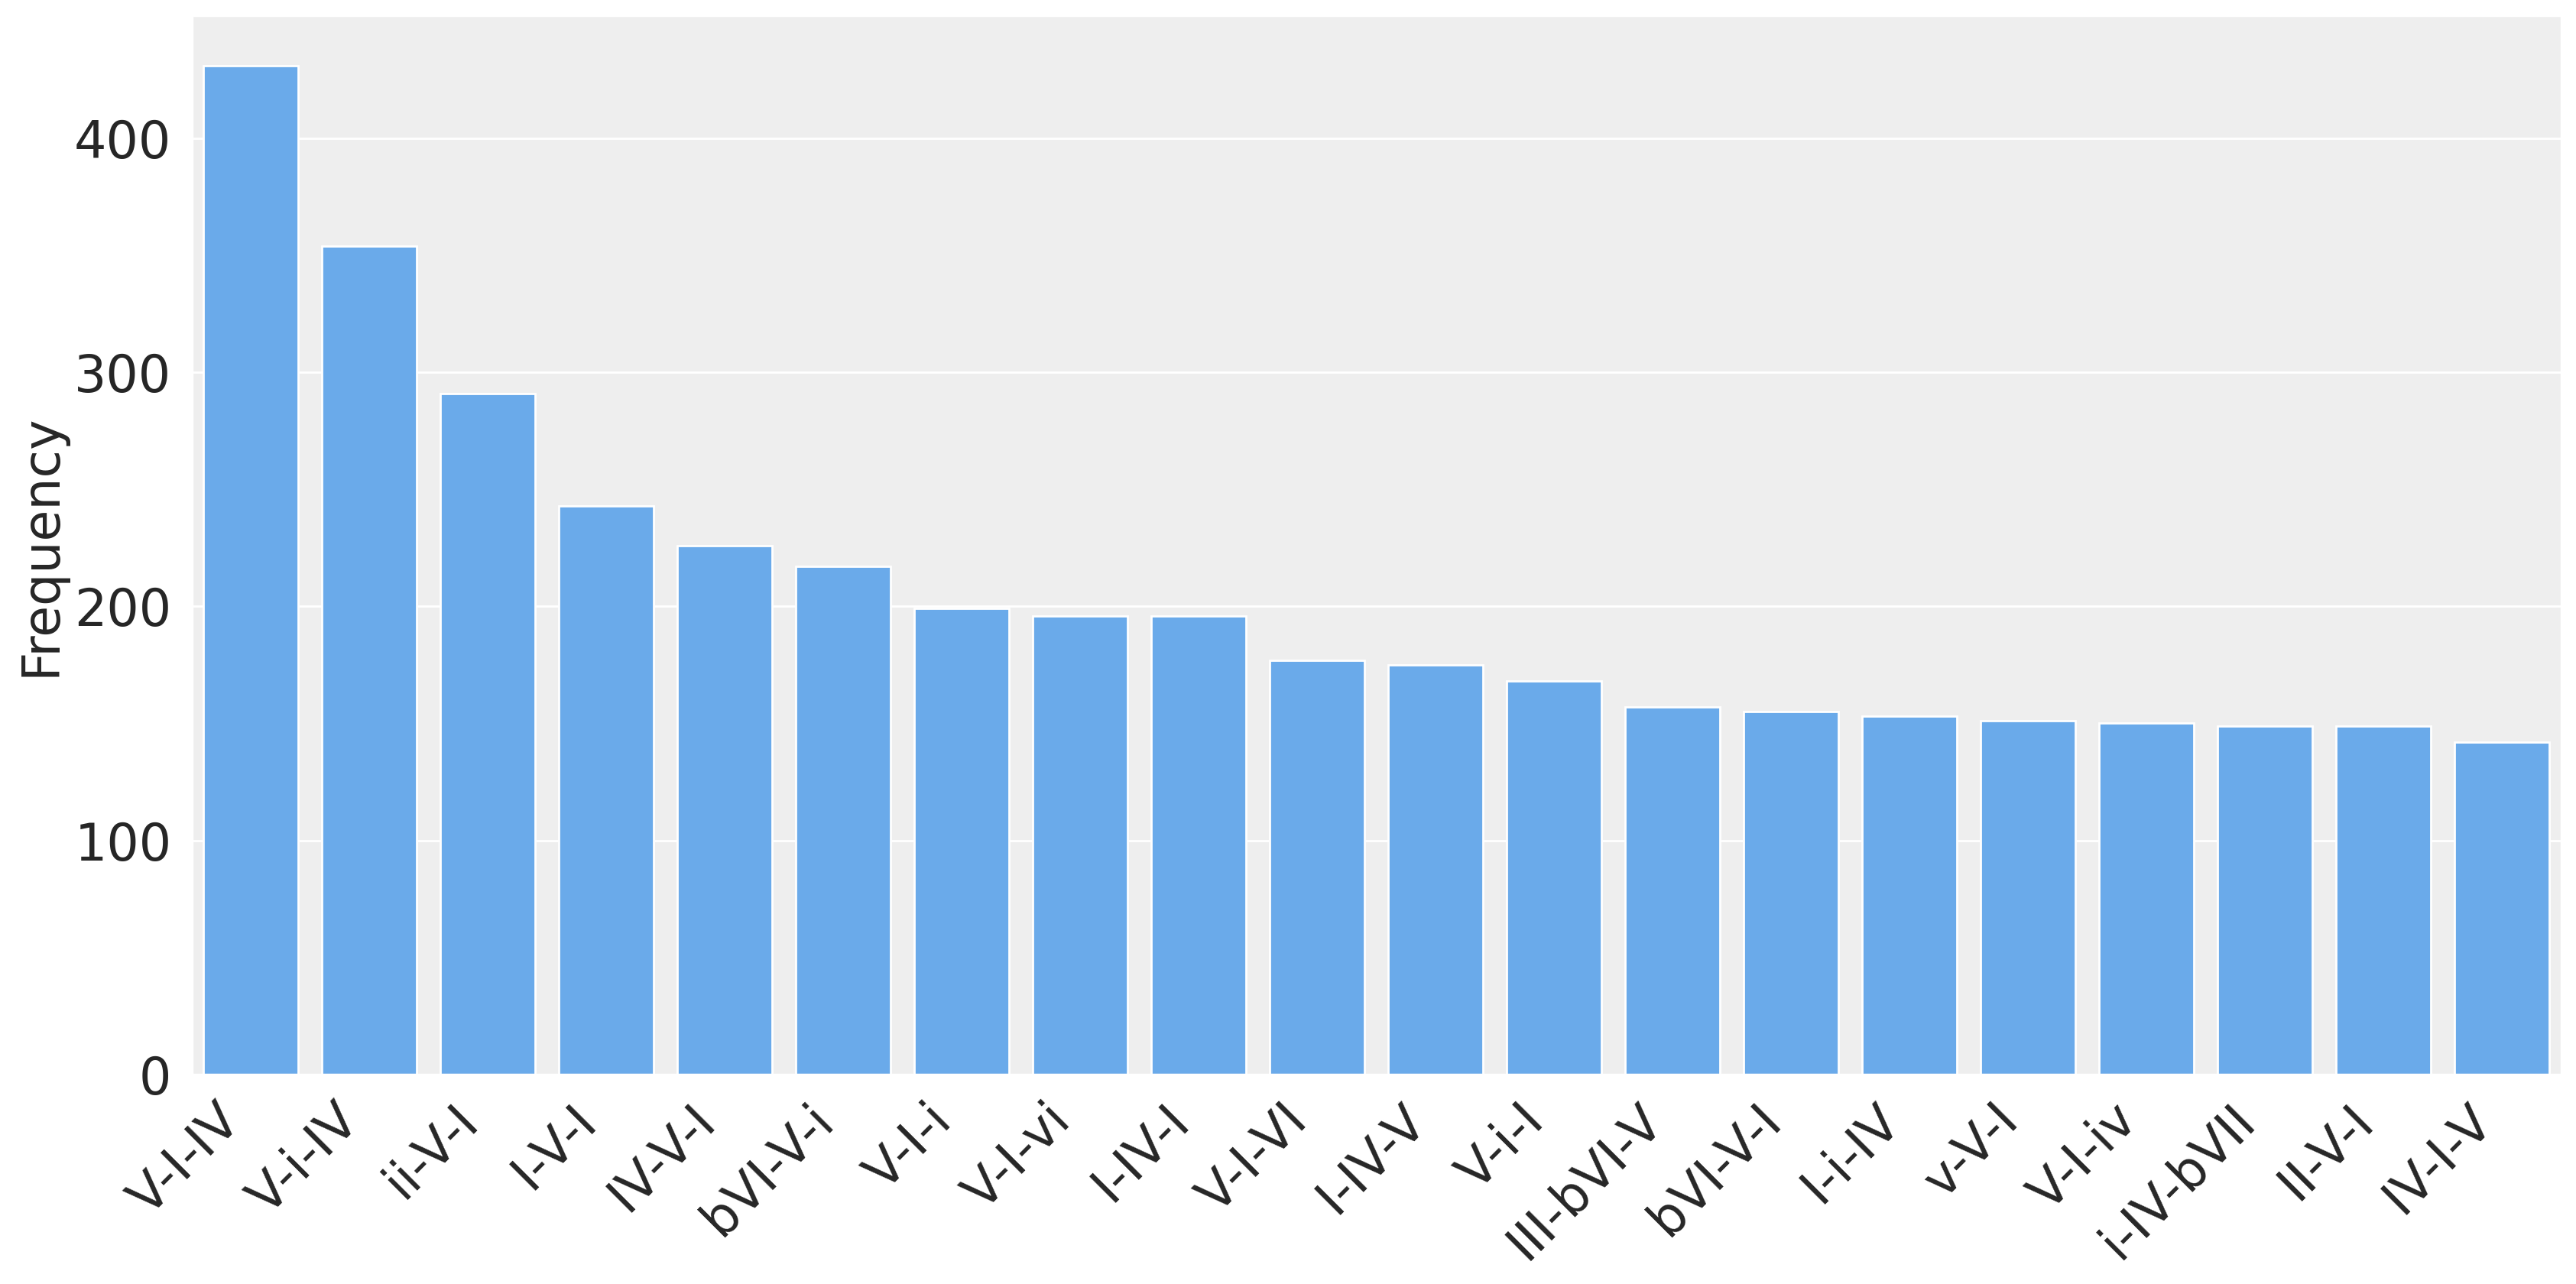

In [32]:
import seaborn as sns

sns.set(rc={'figure.figsize':(20,9)})
sns.set(font_scale=0.8)
sns.set(rc={'axes.facecolor':'#eee', 'figure.facecolor':'white'})

dict_most_common = np.array(dict_most_common, dtype=object)

key = []
for element in dict_most_common[:20]:
    a = element['function'].split(' ')
    a = '-'.join(a)
    key.append(a)

value = []
for element in dict_most_common[:20]:
    value.append(element['value'])

print(key[:10])
#with sns.axes_style("whitegrid"):
b = sns.barplot(x=key, y=value, color='#5af') #palette="rainbow"
b.axes.set_title("",fontsize=22)
b.set_xlabel("",fontsize=16)
b.set_xticklabels(b.get_xticklabels(), rotation=45, horizontalalignment='right')
b.set_ylabel("Frequency",fontsize=24)
b.tick_params(labelsize=24)
plt.show()

In [109]:
np.save("../data/formatted/most_common.npy", most_common)

In [59]:
import numpy as np
import json
import re

trigram = np.load("../data/formatted/trigram.npy", allow_pickle=True)
functions = np.load("../data/formatted/functions.npy", allow_pickle=True)

assert len(trigram) == len(functions), "Arrays must be the same length"

trigram_dataset = []

for t, f in zip(trigram, functions):
    chord_tuple, count = t
    func_id, func_data = f
    key = func_data["key"]
    
    # Replace '-' with 'b' for flats (e.g. 'A-' -> 'Ab')
    key = key.replace("-", "b")

    # Insert space before 'major' or 'minor'
    key_fixed = re.sub(r'([A-G][b#]?)(major|minor)', r'\1 \2', key, flags=re.IGNORECASE)

    entry = {
        "trigram": list(chord_tuple),
        "function": func_data["function"],
        "key": key_fixed,
        "count": int(count)
    }
    trigram_dataset.append(entry)

with open("trigram_dataset.json", "w") as f:
    json.dump(trigram_dataset, f, indent=2)

print(f"Saved {len(trigram_dataset)} entries to trigram_dataset.json")


Saved 46347 entries to trigram_dataset.json


In [53]:
from music21 import roman, key

test_labels = ['IV75#32', 'I75#3b2']
tonality = "F minor"

for label in test_labels:
    try:
        # Let's guess a key, e.g., C major
        rn = roman.RomanNumeral(label, key.Key('F', 'minor'))
        print(f"{label}:", rn.figure, rn.seventh, rn.secondaryRomanNumeral)
    except Exception as e:
        print(f"{label}: Error - {e}")


IV75#32: IV75#32 A-5 None
I75#3b2: I75#3b2 E-5 None
